In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [21]:
metadata = pd.read_excel('../data/metadata_LATINBIOTA_MEXICO.xlsx', sheet_name='Data')


In [22]:
data = pd.read_csv('../datasets/ko_from_humann_not_species.tsv', sep = '\t', index_col = 0)

In [23]:
data.head()

,37082_2#4_paired_Abundance-RPKs,37035_1#5_paired_Abundance-RPKs,36703_3#28_paired_Abundance-RPKs,37035_7#19_paired_Abundance-RPKs,37082_1#25_paired_Abundance-RPKs,37035_2#20_paired_Abundance-RPKs,37035_7#6_paired_Abundance-RPKs,36703_3#19_paired_Abundance-RPKs,37082_1#13_paired_Abundance-RPKs,37035_7#17_paired_Abundance-RPKs,...,37035_2#12_paired_Abundance-RPKs,37082_3#15_paired_Abundance-RPKs,37082_2#28_paired_Abundance-RPKs,37035_7#9_paired_Abundance-RPKs,37082_2#7_paired_Abundance-RPKs,37035_2#14_paired_Abundance-RPKs,37035_2#10_paired_Abundance-RPKs,36703_3#12_paired_Abundance-RPKs,37035_2#31_paired_Abundance-RPKs,37035_2#18_paired_Abundance-RPKs
# Gene Family,,,,,,,,,,,,,,,,,,,,,
K00003,13.412805,371.495165,80.985624,234.528504,103.282816,44.554449,257.701686,158.023982,344.608173,143.681531,...,336.736173,325.924501,92.846165,107.136733,271.256581,194.318531,196.329254,319.968404,269.363349,166.851429
K00005,14.381261,99.948182,98.259350,876.567999,54.887334,51.252921,92.787179,127.042430,138.638928,176.144441,...,141.970727,252.232084,95.148824,139.947702,261.385680,33.294852,67.446929,233.353374,62.862608,67.215980
K00010,55.929057,210.048683,151.299043,196.551879,29.100628,74.569618,100.355774,303.646722,467.014016,78.628856,...,167.282585,139.834818,347.928666,336.730851,364.647018,110.360380,83.761147,408.867947,141.782013,99.943421
K00012,10.118681,104.611479,281.020064,233.516051,536.619805,2264.133888,335.291837,353.044214,452.290904,520.215028,...,239.492136,879.201956,216.160041,215.199584,78.056995,561.333186,775.894888,125.082707,1023.668926,1063.532913
K00013,200.474434,2073.619330,3045.259552,985.665182,1596.552620,3289.035718,2781.175739,1963.640627,2833.764535,2155.075724,...,2377.061577,2384.861119,2929.907096,2751.304878,2571.300553,1724.884605,2172.291854,2406.260042,2527.638782,2298.623257


In [24]:
data.columns = [x.replace('_paired_Abundance-RPKs', '') for x in data.columns]

In [25]:
data.head()

,37082_2#4,37035_1#5,36703_3#28,37035_7#19,37082_1#25,37035_2#20,37035_7#6,36703_3#19,37082_1#13,37035_7#17,...,37035_2#12,37082_3#15,37082_2#28,37035_7#9,37082_2#7,37035_2#14,37035_2#10,36703_3#12,37035_2#31,37035_2#18
# Gene Family,,,,,,,,,,,,,,,,,,,,,
K00003,13.412805,371.495165,80.985624,234.528504,103.282816,44.554449,257.701686,158.023982,344.608173,143.681531,...,336.736173,325.924501,92.846165,107.136733,271.256581,194.318531,196.329254,319.968404,269.363349,166.851429
K00005,14.381261,99.948182,98.259350,876.567999,54.887334,51.252921,92.787179,127.042430,138.638928,176.144441,...,141.970727,252.232084,95.148824,139.947702,261.385680,33.294852,67.446929,233.353374,62.862608,67.215980
K00010,55.929057,210.048683,151.299043,196.551879,29.100628,74.569618,100.355774,303.646722,467.014016,78.628856,...,167.282585,139.834818,347.928666,336.730851,364.647018,110.360380,83.761147,408.867947,141.782013,99.943421
K00012,10.118681,104.611479,281.020064,233.516051,536.619805,2264.133888,335.291837,353.044214,452.290904,520.215028,...,239.492136,879.201956,216.160041,215.199584,78.056995,561.333186,775.894888,125.082707,1023.668926,1063.532913
K00013,200.474434,2073.619330,3045.259552,985.665182,1596.552620,3289.035718,2781.175739,1963.640627,2833.764535,2155.075724,...,2377.061577,2384.861119,2929.907096,2751.304878,2571.300553,1724.884605,2172.291854,2406.260042,2527.638782,2298.623257


In [26]:
rare = ['37082_3#16',
'37082_2#4',
'37035_2#22',
'37035_7#18',
'36703_3#20',
'36703_3#4']

In [27]:
data = data[[x for x in data.columns if x not in rare]]

In [28]:
data = data.T

In [29]:
data

# Gene Family,K00003,K00005,K00010,K00012,K00013,K00014,K00016,K00018,K00027,K00031,...,K07169,K12509,K02993,K06045,K21397,K00188,K01086,K04499,K07937,K21440
37035_1#5,371.495165,99.948182,210.048683,104.611479,2073.619330,788.581789,3302.614098,13.644065,593.315441,779.432056,...,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
36703_3#28,80.985624,98.259350,151.299043,281.020064,3045.259552,3472.505413,3020.973114,26.153793,233.370238,991.583745,...,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
37035_7#19,234.528504,876.567999,196.551879,233.516051,985.665182,875.025798,1510.092548,0.000000,643.594138,600.955488,...,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
37082_1#25,103.282816,54.887334,29.100628,536.619805,1596.552620,850.037071,411.335574,23.576791,102.900607,481.698014,...,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
37035_2#20,44.554449,51.252921,74.569618,2264.133888,3289.035718,2226.808098,973.147105,0.000000,242.205794,1168.785878,...,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37035_2#14,194.318531,33.294852,110.360380,561.333186,1724.884605,591.268563,565.194631,102.307921,875.034097,783.388487,...,0.0,0.0,7.246377,21.370606,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
37035_2#10,196.329254,67.446929,83.761147,775.894888,2172.291854,1095.566275,1120.267956,0.000000,661.890503,996.185554,...,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
36703_3#12,319.968404,233.353374,408.867947,125.082707,2406.260042,2028.944612,2546.093738,82.708557,376.282980,1031.972065,...,0.0,0.0,0.000000,0.000000,8.662077,0.00000,0.000000,0.000000,0.000000,0.000000
37035_2#31,269.363349,62.862608,141.782013,1023.668926,2527.638782,1284.968626,1181.720550,82.463011,302.777015,1039.235661,...,0.0,0.0,0.000000,0.000000,0.000000,10.10101,32.116242,4.739336,2.951903,7.828069


In [30]:
data.describe()

# Gene Family,K00003,K00005,K00010,K00012,K00013,K00014,K00016,K00018,K00027,K00031,...,K07169,K12509,K02993,K06045,K21397,K00188,K01086,K04499,K07937,K21440
count,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,...,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000,199.000000
mean,282.073581,124.957152,249.862331,485.370388,2339.651806,1751.839800,1992.552620,45.402526,428.127395,1008.006360,...,0.019477,0.022235,0.036414,0.107390,0.043528,0.050759,0.161388,0.023816,0.014834,0.039337
std,198.856753,148.216657,298.967372,455.065759,888.243944,1165.944963,1110.354194,72.460511,257.223413,607.751714,...,0.274760,0.313664,0.513682,1.514922,0.614038,0.716042,2.276660,0.335963,0.209255,0.554917
min,27.343761,0.000000,6.925853,20.163889,566.833432,269.837969,286.113611,0.000000,53.413381,103.195827,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,142.223532,54.542652,86.763855,182.771305,1720.657276,934.972845,1216.923922,0.000000,264.943388,530.752392,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,232.264108,86.132708,162.758733,351.858799,2330.147338,1476.784482,1771.233835,13.502565,360.422573,850.582037,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,361.546891,143.324304,314.390605,598.141222,2954.306778,2234.658654,2595.737091,64.982987,558.969528,1377.144109,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1083.503971,1504.271496,3002.046189,2823.481341,4882.968479,7264.153736,6005.704076,410.993766,1781.665434,3067.932824,...,3.875969,4.424779,7.246377,21.370606,8.662077,10.101010,32.116242,4.739336,2.951903,7.828069


In [31]:
import pandas as pd
import numpy as np

# Contar ceros por columna
zero_counts = (data == 0).sum()

print("Conteo de ceros por columna:")
print(zero_counts.sort_values(ascending=False))

# Identificar columnas a eliminar (50 o más ceros)
cols_to_drop = zero_counts[zero_counts >= 10].index.tolist()

print(f"\nColumnas a eliminar ({len(cols_to_drop)}):")
print(cols_to_drop)

# Eliminar columnas
data_filtered = data.drop(columns=cols_to_drop)

print(f"\nShape original: {data.shape}")
print(f"Shape después de filtrar: {data_filtered.shape}")
print(f"Columnas eliminadas: {len(cols_to_drop)}")

Conteo de ceros por columna:
# Gene Family
K22476    199
K00235    199
K01947    199
K11904    199
K12583    199
         ... 
K00058      0
K00262      0
K00016      0
K00014      0
K00013      0
Length: 5726, dtype: int64

Columnas a eliminar (4522):
['K00018', 'K00100', 'K00161', 'K00176', 'K00180', 'K00184', 'K00351', 'K00425', 'K00633', 'K00652', 'K00812', 'K00836', 'K00839', 'K00932', 'K00968', 'K01002', 'K01035', 'K01155', 'K01179', 'K01191', 'K01200', 'K01220', 'K01247', 'K01251', 'K01270', 'K01372', 'K01429', 'K01482', 'K01596', 'K01607', 'K01706', 'K01819', 'K01821', 'K01843', 'K01844', 'K01906', 'K01975', 'K02086', 'K02221', 'K02341', 'K02401', 'K02406', 'K02411', 'K02416', 'K02567', 'K02614', 'K02650', 'K02662', 'K02794', 'K03072', 'K03092', 'K03307', 'K03411', 'K03416', 'K03436', 'K03480', 'K03481', 'K03522', 'K03558', 'K03743', 'K03833', 'K04027', 'K04028', 'K04061', 'K04074', 'K05020', 'K05515', 'K05820', 'K05847', 'K05934', 'K06284', 'K06330', 'K06378', 'K06381', 'K0638

In [49]:
import pandas as pd
import numpy as np

# Compute absolute correlation matrix
corr_matrix = data_filtered.corr().abs()

# Create a boolean mask for the upper triangle
upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

# Set the lower triangle and diagonal to NaN for convenience
corr_matrix.values[np.tril_indices_from(corr_matrix)] = np.nan

# Find features to drop — keep only one of each correlated pair
threshold = 0.9
to_drop = set()

for col in corr_matrix.columns:
    # Check if this column is highly correlated with any previous (not dropped)
    if any(corr_matrix[col] > threshold):
        to_drop.add(col)

data_filtered_red =  data_filtered.drop(columns=to_drop)

print(f"Kept { data_filtered_red.shape[1]} features (dropped {len(to_drop)}).")


Kept 1016 features (dropped 188).


In [50]:
labels = []
for item in data.index:
    labels.append(metadata[metadata['Lane'] == item]['Lifestyle'].iloc[0])

In [51]:
import math
age_group_list = []
for id_ in data.index:
    try:
        if math.isnan(metadata[metadata['Lane'] == id_]['Age group'].iloc[0]):
            age_group_list.append('Adult')
    except:
        if metadata[metadata['Lane'] == id_]['Age group'].iloc[0] == 'Infant':
            age_group_list.append('Child')
        elif metadata[metadata['Lane'] == id_]['Age group'].iloc[0] == 'Teenager':
            age_group_list.append('Adult')
        else:
            age_group_list.append(metadata[metadata['Lane'] == id_]['Age group'].iloc[0])

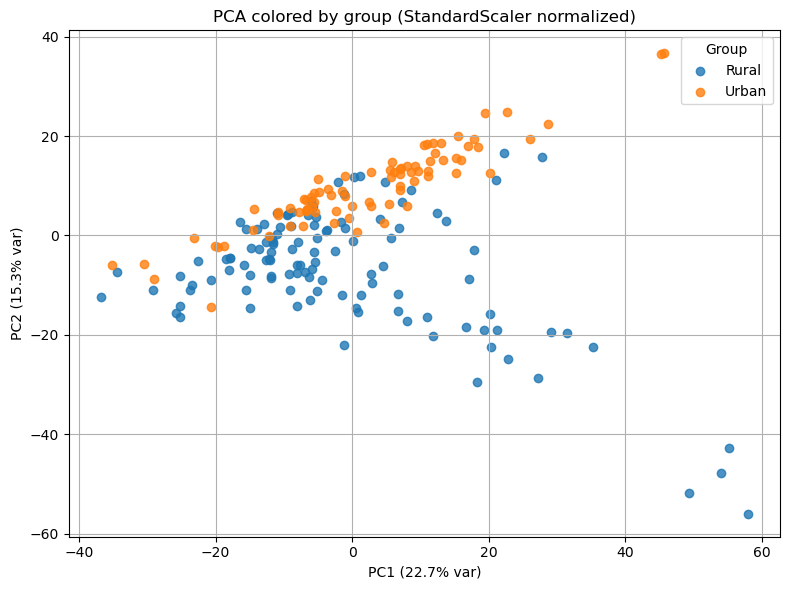

In [14]:

# Example setup
# data = pd.read_csv("your_data.csv", index_col=0)
# labels = [...]  # list or Series with same length as number of rows in data
data
# 1️⃣ Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_filtered)

# 2️⃣ PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# 3️⃣ Combine into a DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"],
    index=data.index
)
pca_df["label"] = labels

# 4️⃣ Plot each group with a different color
plt.figure(figsize=(8,6))

for group in pca_df["label"].unique():
    idx = pca_df["label"] == group
    plt.scatter(
        pca_df.loc[idx, "PC1"],
        pca_df.loc[idx, "PC2"],
        label=group,
        alpha=0.8
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA colored by group (StandardScaler normalized)")
plt.legend(title="Group")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\rafap\AppData\Local\Temp\ipykernel_25216\3770574663.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Group",


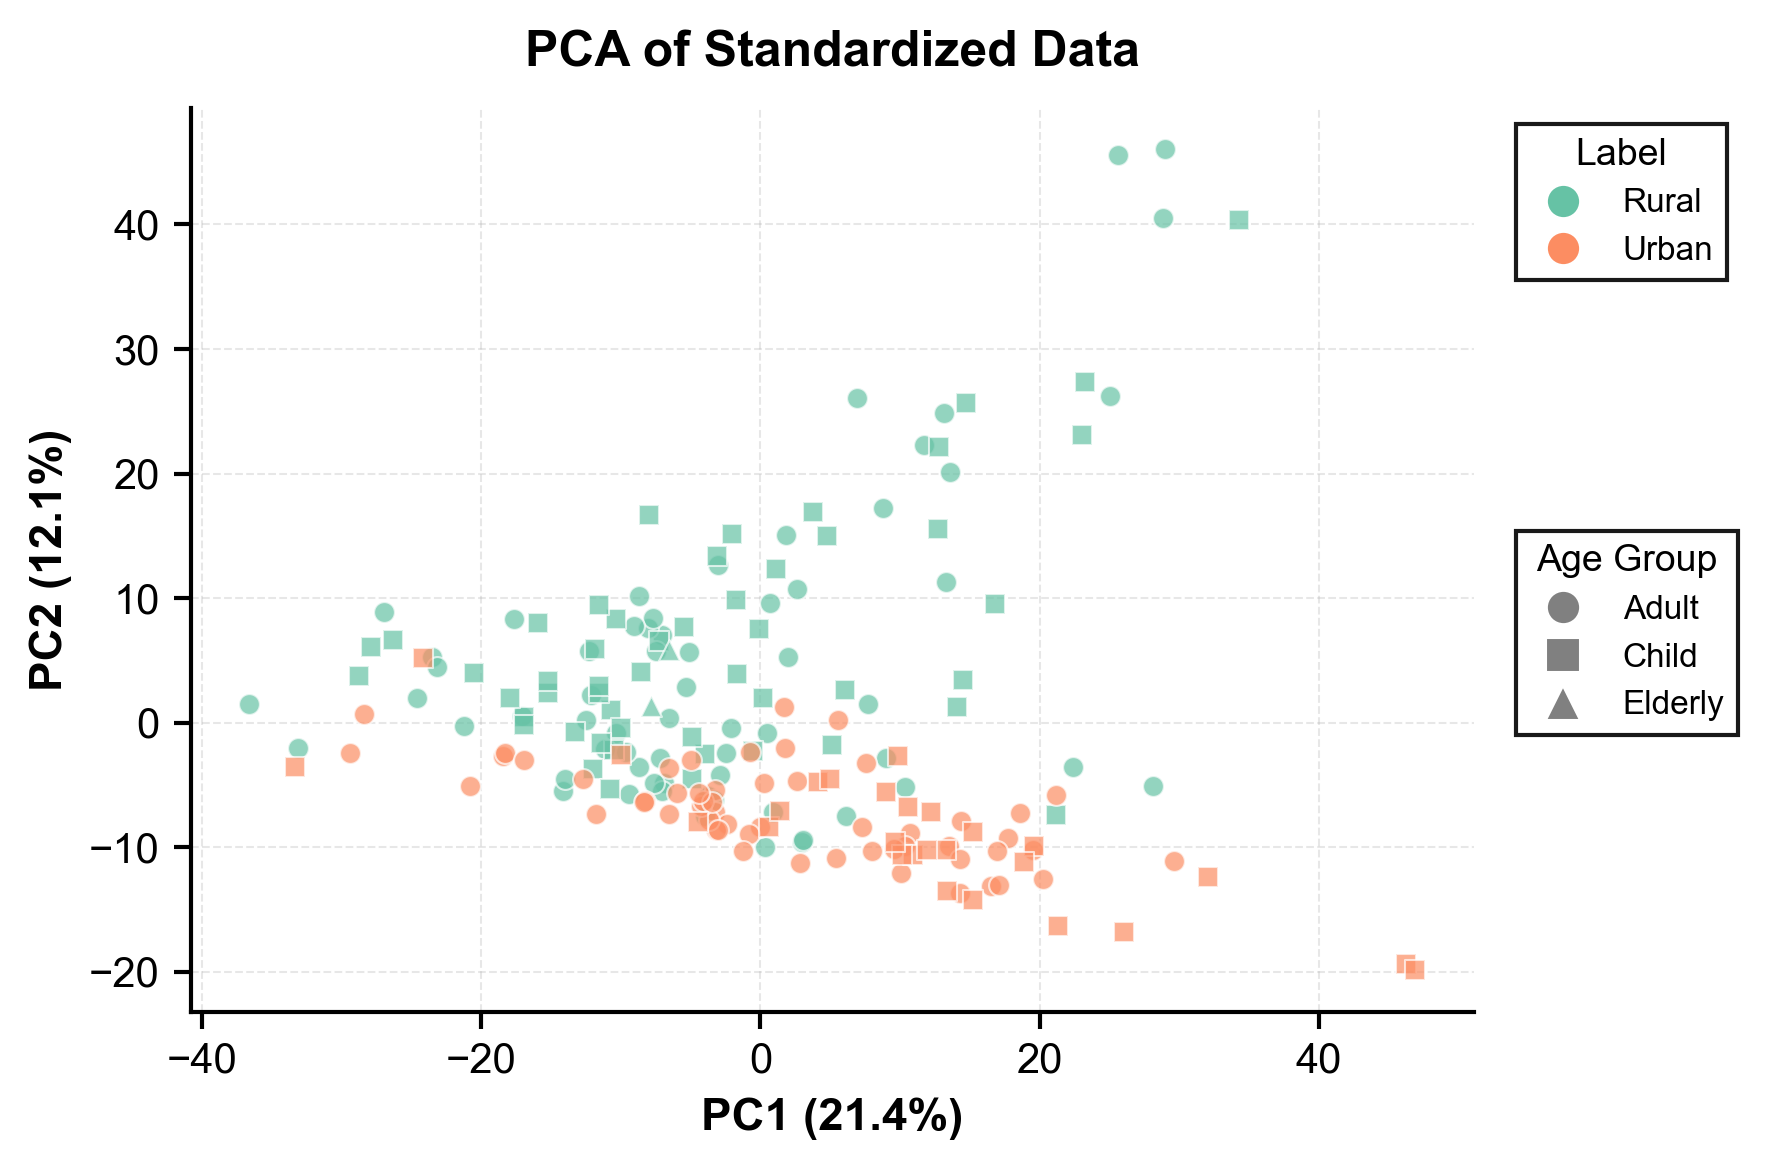

In [54]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

# 1️⃣ Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_filtered_red)

# 2️⃣ PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# 3️⃣ Combine into a DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"],
    index=data_filtered_red.index
)
pca_df["label"] = labels
# If you have age groups:
pca_df["age_group"] = age_group_list

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Get unique labels and colors
labels_unique = sorted(pca_df["label"].unique())
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# If using age groups:
age_groups_unique = sorted(pca_df["age_group"].unique())
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# Plot without age groups
# for i, group in enumerate(labels_unique):
#     idx = pca_df["label"] == group
#     ax.scatter(
#         pca_df.loc[idx, "PC1"],
#         pca_df.loc[idx, "PC2"],
#         label=group,
#         color=colors[i % len(colors)],
#         alpha=0.7,
#         s=50,
#         edgecolors='white',
#         linewidths=0.5
#     )

# OR: Plot with age groups (uncomment if needed)
for i, group in enumerate(labels_unique):
    for j, age in enumerate(age_groups_unique):
        idx = (pca_df["label"] == group) & (pca_df["age_group"] == age)
        if idx.any():
            ax.scatter(
                pca_df.loc[idx, "PC1"],
                pca_df.loc[idx, "PC2"],
                color=colors[i % len(colors)],
                marker=markers[j % len(markers)],
                alpha=0.7,
                s=25,
                edgecolors='white',
                linewidths=0.5
            )

# Format axes
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", 
              fontsize=11, fontweight='bold')
ax.set_title("PCA of Standardized Data", 
             fontsize=12, fontweight='bold', pad=10)

# Legend (simple version)
ax.legend(title="Group",
          title_fontsize=10,
          frameon=True,
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.9)

# OR: Two legends for age groups (uncomment if using age groups)
label_legend_elements = [Line2D([0], [0], marker='o', color='w', 
                                markerfacecolor=colors[i % len(colors)], 
                                markersize=8, label=lbl,
                                markeredgecolor='white', markeredgewidth=0.5)
                        for i, lbl in enumerate(labels_unique)]

age_legend_elements = [Line2D([0], [0], marker=markers[j % len(markers)], 
                              color='w', markerfacecolor='gray', 
                              markersize=8, label=age,
                              markeredgecolor='white', markeredgewidth=0.5)
                      for j, age in enumerate(age_groups_unique)]

first_legend = ax.legend(handles=label_legend_elements, 
                        title='Label',
                        loc='upper left',
                        bbox_to_anchor=(1.02, 1),
                        fontsize=8,
                        title_fontsize=9,
                        frameon=True,
                        edgecolor='black',
                        fancybox=False,
                        framealpha=0.9)

ax.add_artist(first_legend)
ax.legend(handles=age_legend_elements,
         title='Age Group',
         loc='upper left',
         bbox_to_anchor=(1.02, 0.55),
         fontsize=8,
         title_fontsize=9,
         frameon=True,
         edgecolor='black',
         fancybox=False,
         framealpha=0.9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_standardized.pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_standardized.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_standardized.svg', bbox_inches='tight')

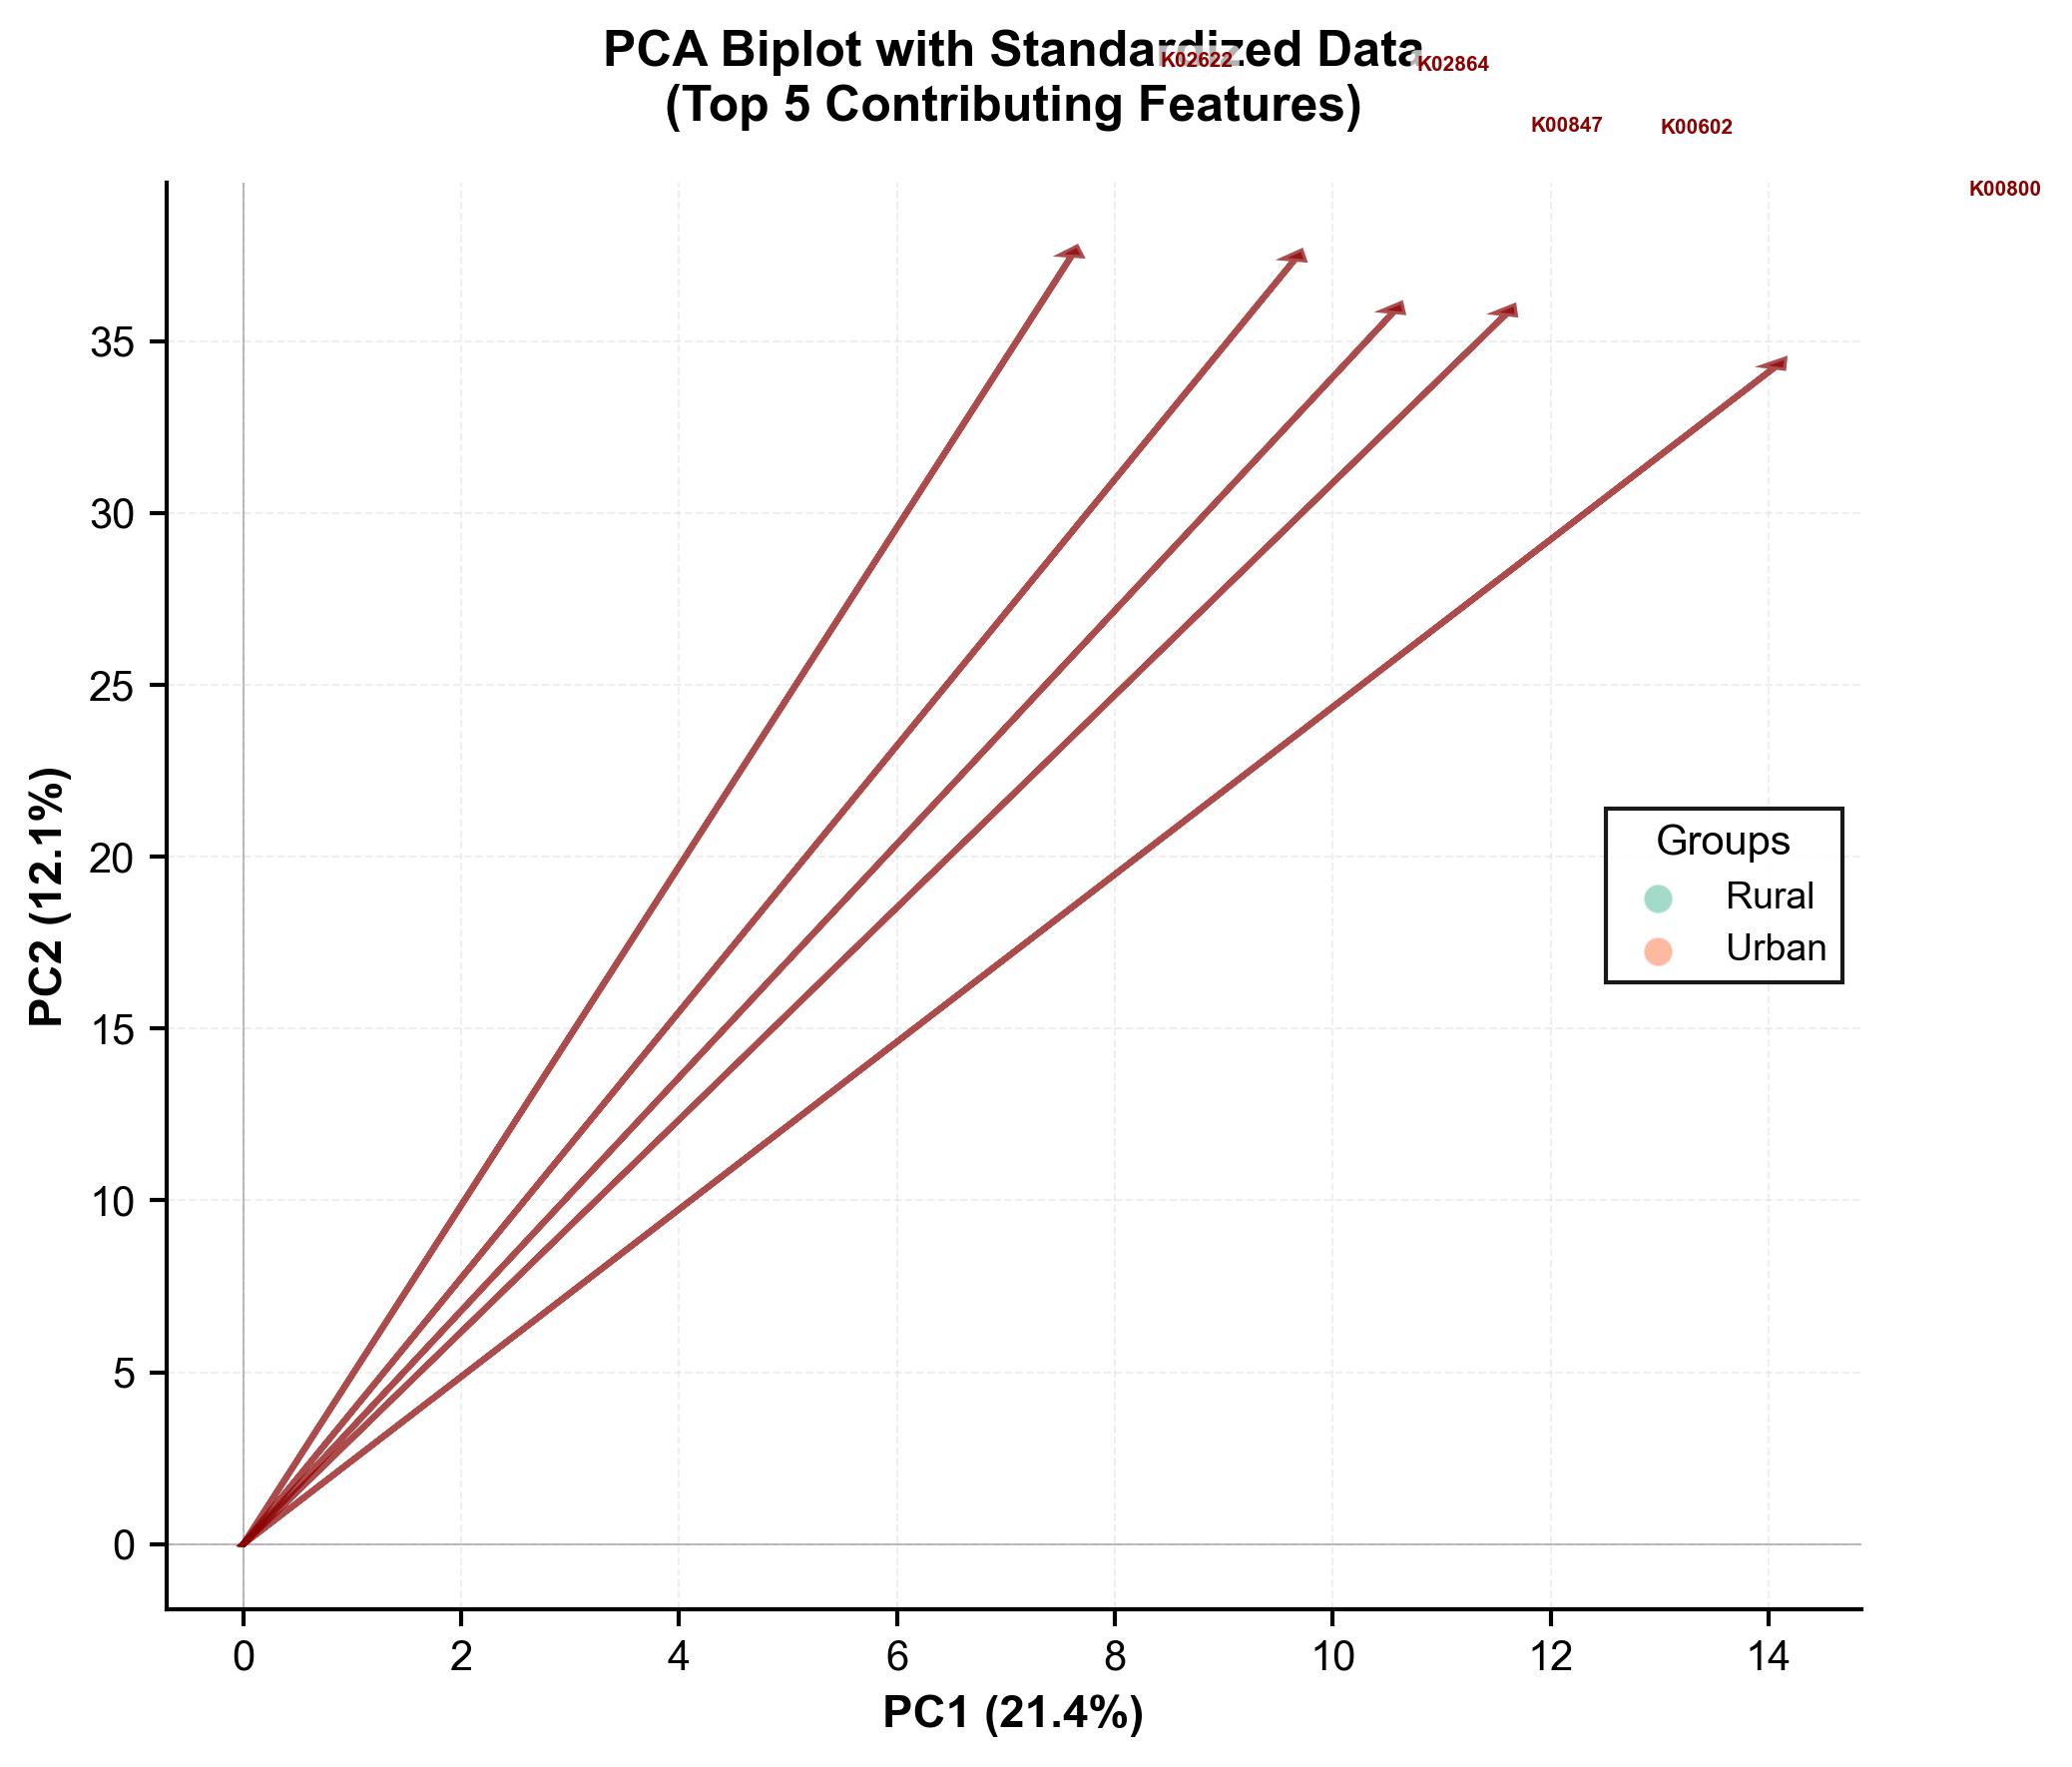

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
#from adjustText import adjustText  # Optional: for better label positioning

# Prepare data
X = data_filtered_red.values
y = labels
feature_names = data_filtered_red.columns

# Apply Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Loadings (contributions of original variables)
loadings = pca.components_.T  # shape: n_features x 2

# Compute contribution of each feature to PC1+PC2
contrib = np.linalg.norm(loadings, axis=1)  # Euclidean norm across PCs

# Select top 5 features by contribution
top_n = 5
top_idx = np.argsort(contrib)[-top_n:][::-1]  # indices of top features
top_features = feature_names[top_idx]

# Set journal-style parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.major.size'] = 4
plt.rcParams['ytick.major.size'] = 4

# Create figure
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# Get unique labels and colors
labels_unique = sorted(set(y))
colors = plt.cm.Set2.colors if len(labels_unique) <= 8 else plt.cm.tab10.colors

# Scatter plot of samples
for i, group in enumerate(labels_unique):
    idx = y == group
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], 
              alpha=0.6, 
              s=50, 
              label=group,
              color=colors[i % len(colors)],
              edgecolors='white',
              linewidths=0.5,
              zorder=2)

# Draw arrows for top features
scaling = np.max(np.abs(X_pca)) / np.max(np.abs(loadings)) * 0.8  # Auto-scale arrows
texts = []

for i in top_idx:
    # Draw arrow
    ax.arrow(0, 0, 
            loadings[i, 0] * scaling, 
            loadings[i, 1] * scaling, 
            color='darkred', 
            alpha=0.7, 
            head_width=0.15,
            head_length=0.2,
            linewidth=1.5,
            zorder=3)
    
    # Add text label
    text = ax.text(loadings[i, 0] * scaling * 1.15, 
                   loadings[i, 1] * scaling * 1.15, 
                   feature_names[i],
                   fontsize=5, 
                   color='darkred',
                   ha='center',
                   va='center',
                   fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', 
                           facecolor='white', 
                           edgecolor='none',
                           alpha=0.7),
                   zorder=4)
    texts.append(text)

# Optional: Use adjustText to prevent label overlap
# Uncomment if you have adjustText installed: pip install adjustText
# adjustText(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

# Format axes
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', 
              fontsize=11, fontweight='bold')
ax.set_title('PCA Biplot with Standardized Data\n(Top 5 Contributing Features)', 
             fontsize=12, fontweight='bold', pad=15)

# Legend
ax.legend(frameon=True, 
          loc='best',
          fontsize=9,
          edgecolor='black',
          fancybox=False,
          shadow=False,
          framealpha=0.9,
          title='Groups',
          title_fontsize=10)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add subtle grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)

# Add reference lines at origin
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()

# Optional: Save as high-resolution files for publication
# fig.savefig('pca_biplot_standardized.pdf', dpi=300, bbox_inches='tight')
fig.savefig('pca_biplot_standardized_functions.png', dpi=400, bbox_inches='tight')
# fig.savefig('pca_biplot_standardized.svg', bbox_inches='tight')

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

labels = data_filtered['label']
X = data_filtered.drop(columns=['label'])

# 1️⃣ Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# 2️⃣ PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# 3️⃣ Combine into a DataFrame
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"],
    index=data_filtered.index
)
pca_df["label"] = labels

# 4️⃣ Get loadings (contributions of features to PCs)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=X.columns
)

# 5️⃣ Calculate total variance contribution for each feature
loading_df['total_variance'] = np.sqrt(loading_df['PC1']**2 + loading_df['PC2']**2)

# 6️⃣ Select top 10 features with highest variance contribution
top_features = loading_df.nlargest(10, 'total_variance')

print("Top 10 features by variance contribution:")
print(top_features)

# 7️⃣ Define outlier thresholds
# Option 1: Fixed thresholds
PC1_threshold = 50  # Adjust based on your data
PC2_threshold = 50  # Adjust based on your data

# Option 2: Dynamic thresholds (based on percentiles)
PC1_lower = pca_df['PC1'].quantile(0.05)  # 5th percentile
PC1_upper = pca_df['PC1'].quantile(0.95)  # 95th percentile
PC2_lower = pca_df['PC2'].quantile(0.05)
PC2_upper = pca_df['PC2'].quantile(0.95)

# Option 3: Based on standard deviations
PC1_mean, PC1_std = pca_df['PC1'].mean(), pca_df['PC1'].std()
PC2_mean, PC2_std = pca_df['PC2'].mean(), pca_df['PC2'].std()
n_std = 2  # Number of standard deviations

# Choose your outlier detection method here:
# Method 1: Fixed thresholds
outliers = (np.abs(pca_df['PC1']) > PC1_threshold) | (np.abs(pca_df['PC2']) > PC2_threshold)

# Method 2: Percentile-based (uncomment to use)
# outliers = (pca_df['PC1'] < PC1_lower) | (pca_df['PC1'] > PC1_upper) | \
#            (pca_df['PC2'] < PC2_lower) | (pca_df['PC2'] > PC2_upper)

# Method 3: Standard deviation-based (uncomment to use)
# outliers = (np.abs(pca_df['PC1'] - PC1_mean) > n_std * PC1_std) | \
#            (np.abs(pca_df['PC2'] - PC2_mean) > n_std * PC2_std)

print(f"\nOutliers detected: {outliers.sum()}")
print("Outlier samples:")
print(pca_df[outliers][['PC1', 'PC2', 'label']])

# 8️⃣ Create biplot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot samples (points)
for group in pca_df["label"].unique():
    idx = pca_df["label"] == group
    ax.scatter(
        pca_df.loc[idx, "PC1"],
        pca_df.loc[idx, "PC2"],
        label=group,
        alpha=0.7,
        s=100,
        edgecolors='black',
        linewidth=0.5
    )

# 9️⃣ Label outliers
outlier_samples = pca_df[outliers]
for idx, row in outlier_samples.iterrows():
    ax.annotate(
        idx,  # Sample name from index
        xy=(row['PC1'], row['PC2']),
        xytext=(10, 10),  # Offset in points
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='red',
        bbox=dict(boxstyle='round,pad=0.4', 
                  facecolor='yellow', 
                  edgecolor='red',
                  alpha=0.8,
                  linewidth=1.5),
        arrowprops=dict(arrowstyle='->', 
                       connectionstyle='arc3,rad=0.3',
                       color='red',
                       lw=1.5)
    )

# 🔟 Plot top features (arrows)
scale_factor = 20 # Adjust this to make arrows longer/shorter
colors = plt.cm.Dark2(np.linspace(0, 1, 10))

for i, (feature, color) in enumerate(zip(top_features.index, colors)):
    ax.arrow(
        0, 0,
        top_features.loc[feature, 'PC1'] * scale_factor,
        top_features.loc[feature, 'PC2'] * scale_factor,
        head_width=2,
        head_length=1.5,
        fc=color,
        ec='black',
        alpha=0.8,
        width=0.3,
        linewidth=1.5
    )
    
    # Add feature labels at the end of arrows
    ax.text(
        top_features.loc[feature, 'PC1'] * scale_factor * 1.12,
        top_features.loc[feature, 'PC2'] * scale_factor * 1.12,
        feature,
        fontsize=9,
        fontweight='bold',
        ha='center',
        va='center',
        bbox=dict(boxstyle='round,pad=0.4', 
                  facecolor=color, 
                  edgecolor='black',
                  alpha=0.7,
                  linewidth=1.5)
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", 
              fontsize=13, fontweight='bold')
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", 
              fontsize=13, fontweight='bold')
ax.set_title("PCA Biplot - Top 10 Features with Outliers Labeled", 
             fontsize=15, fontweight='bold', pad=20)

ax.axhline(y=0, color='k', linewidth=1, linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linewidth=1, linestyle='--', alpha=0.3)

# Add threshold lines (optional - uncomment if using fixed thresholds)
# ax.axhline(y=PC2_threshold, color='red', linewidth=1, linestyle=':', alpha=0.5, label='Outlier threshold')
# ax.axhline(y=-PC2_threshold, color='red', linewidth=1, linestyle=':', alpha=0.5)
# ax.axvline(x=PC1_threshold, color='red', linewidth=1, linestyle=':', alpha=0.5)
# ax.axvline(x=-PC1_threshold, color='red', linewidth=1, linestyle=':', alpha=0.5)

ax.legend(title="Groups", bbox_to_anchor=(1.05, 1), loc='upper left', 
          framealpha=0.95, fontsize=10)
ax.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

KeyError: 'label'

In [ ]:
outlier_samples

In [16]:
metadata[metadata['Lane'].isin(outlier_samples.index)]

NameError: name 'outlier_samples' is not defined

In [58]:
from scipy.stats import ttest_ind

data_filtered_red['label'] = labels
# Example:
# data = pd.read_csv("your_data.csv")  
# where 'label' is the column with group names (e.g. 'Control' / 'Treatment')

# 1️⃣ Separate labels and genes
labels = data_filtered_red['label']
genes = data_filtered_red.drop(columns=['label'])

# 2️⃣ Identify your two groups
group1, group2 = labels.unique()
print("Groups:", group1, "vs", group2)

# 3️⃣ Split the data
data1 = genes[labels == group1]
data2 = genes[labels == group2]

# 4️⃣ Perform t-test for each gene (columns)
results = []
for gene in genes.columns:
    stat, pval = ttest_ind(data1[gene], data2[gene], equal_var=False)
    mean_diff = data1[gene].mean() - data2[gene].mean()
    results.append((gene, mean_diff, pval))

# 5️⃣ Make a results DataFrame
res_df = pd.DataFrame(results, columns=['Gene', 'Mean_Difference', 'p_value'])
res_df['p_adj'] = res_df['p_value'] * len(res_df)  # Bonferroni correction (simple)
res_df = res_df.sort_values('p_value')

# 6️⃣ Show top differential genes
print(res_df.head(10))


Groups: Rural vs Urban
       Gene  Mean_Difference       p_value         p_adj
433  K03088     -3641.032172  1.784501e-23  1.813053e-20
986  K10773       546.737675  2.204822e-21  2.240100e-18
282  K01950      -803.158143  2.485557e-19  2.525326e-16
760  K16212      -564.961046  6.119019e-18  6.216924e-15
752  K14652     -1172.114334  3.138930e-17  3.189153e-14
52   K00606      -824.909100  5.200256e-17  5.283460e-14
21   K00099      -858.108953  9.412714e-17  9.563317e-14
368  K02622       737.627743  1.018354e-16  1.034648e-13
385  K02864      1230.457548  1.202483e-16  1.221723e-13
153  K01190      -796.411612  1.619802e-16  1.645719e-13


In [19]:
res_df.to_csv('gene_diff.tsv', sep='\t', index = False)